# Comparative Analysis of Multi-Objective Optimizers for Location Optimization

This notebook performs a systematic comparison of four multi-objective optimization algorithms
applied to the map-based location optimization problem from Sun et al. (DOCS 2023):

- **PSO-DN**: Particle Swarm Optimization with Dynamic Neighborhood (the proposed algorithm)
- **MOPSO-CD**: Multi-Objective PSO with Crowding Distance
- **NSGA-II**: Non-dominated Sorting Genetic Algorithm II (pymoo)
- **NSGA-III**: Non-dominated Sorting Genetic Algorithm III (pymoo)

The analysis covers: hyperparameter tuning for PSO-DN, algorithm comparison on the original map,
benchmark on the DTLZ3 problem with multiple local Pareto fronts, and validation on the ZDT1 benchmark.

In [1]:
import sys, os, json, copy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial import distance
from shapely.geometry import Point, LineString, MultiLineString

# pymoo
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from pymoo.core.problem import Problem
from pymoo.core.callback import Callback
from pymoo.problems import get_problem

# Project modules
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.problem import LocationProblem
from src.archives import Archive
from src.optimizers.pso_dn import PSODN
from src.optimizers.mopso_cd import MOPSO_CD
from src.plot_utils import plot_city_map_with_solutions, plot_city_map
from data.test_map import facilities, infrastructure, map_styles, x_bounds, v_bounds
from src.mo_utils import get_sorted_fronts_and_scd, scd_for_front

In [2]:
# ==========================================
# Problem & Algorithm Constants
# ==========================================
D = 2
M = 4
K = [6, 3, 13, 3]

POP_SIZE = 110 * D        # = 220
N_ITER_TUNING = 40
N_ITER_COMPARISON = 50

W = 0.729
C1 = 1.49445
C2 = 1.49445

R_L_CANDIDATES = [2.0, 5.0, 10.0, 15.0, 20.0, 30.0]
BEST_R_L = 10.0           # will be confirmed by tuning

N_RUNS_TUNING = 30
N_RUNS_MAIN = 30
N_RUNS_QUICK = 15

np.random.seed(42)
MASTER_SEEDS = np.random.randint(0, 100000, size=max(N_RUNS_TUNING, N_RUNS_MAIN, N_RUNS_QUICK))

# Initialize the location problem
problem = LocationProblem(
    D=D, M=M, K=K,
    facilities=facilities,
    infrastructure=infrastructure,
    map_styles=map_styles,
    x_bounds=x_bounds
)

# Pymoo wrapper for the location problem
class PymooLocationWrapper(Problem):
    def __init__(self, loc_prob):
        self.loc_prob = loc_prob
        super().__init__(
            n_var=loc_prob.D,
            n_obj=loc_prob.M,
            n_ieq_constr=0,
            xl=np.array(loc_prob.x_bounds)[:, 0],
            xu=np.array(loc_prob.x_bounds)[:, 1]
        )

    def _evaluate(self, x, out, *args, **kwargs):
        out["F"] = self.loc_prob.evaluate_population(x)

pymoo_problem = PymooLocationWrapper(problem)

# Reference points for Hypervolume
REF_200 = np.array([200, 200, 200, 200])
REF_400 = np.array([400, 400, 400, 400])
hv_200 = HV(ref_point=REF_200)
hv_400 = HV(ref_point=REF_400)

# Cache directory for results
CACHE_DIR = os.path.join(project_root, 'results')
os.makedirs(CACHE_DIR, exist_ok=True)

FORCE_RECOMPUTE = False  # set True to re-run all (overwrites cached results)

---
## 1. Hyperparameter Tuning: R_l for PSO-DN

The dynamic radius parameter $R_l$ controls the initial neighborhood size used in the sub-population assignment
(Algorithm 2 in the paper). It determines how coarsely the swarm is partitioned: small $R_l$ creates many
small sub-populations (more exploration), while large $R_l$ creates few large sub-populations (more exploitation).

We tune $R_l$ over 30 independent runs with fixed seeds, selecting the value with the highest mean Hypervolume.

In [3]:
# ==========================================
# Hyperparameter Tuning Loop
# ==========================================
TUNING_CACHE = os.path.join(CACHE_DIR, 'tuning_results.json')

if FORCE_RECOMPUTE or not os.path.exists(TUNING_CACHE):
    tuning_results_200 = {rl: [] for rl in R_L_CANDIDATES}
    tuning_results_400 = {rl: [] for rl in R_L_CANDIDATES}
    tuning_solutions_X = {rl: [] for rl in R_L_CANDIDATES}
    tuning_solutions_F = {rl: [] for rl in R_L_CANDIDATES}

    print("Starting Hyperparameter Tuning for R_l...\n")
    for i, seed in enumerate(tqdm(MASTER_SEEDS[:N_RUNS_TUNING], desc="Tuning runs")):
        for rl in R_L_CANDIDATES:
            np.random.seed(seed)

            optimizer = PSODN(pop_size=POP_SIZE, n_iter=N_ITER_TUNING, R_l=rl,
                              w=W, c1=C1, c2=C2, v_bounds=v_bounds)
            archive, _ = optimizer.optimize(problem, verbose=False)
            X, F = archive.extract_arrays()
            X_clean, F_clean = problem.impose_infrastructure_constraints(X, F)

            tuning_solutions_X[rl].append(X_clean)
            tuning_solutions_F[rl].append(F_clean)

            score_200 = hv_200(F_clean) if len(F_clean) > 0 else 0.0
            score_400 = hv_400(F_clean) if len(F_clean) > 0 else 0.0
            tuning_results_200[rl].append(score_200)
            tuning_results_400[rl].append(score_400)

    # Save to cache
    cache = {
        'R_L_CANDIDATES': R_L_CANDIDATES,
        'results_200': {str(rl): tuning_results_200[rl] for rl in R_L_CANDIDATES},
        'results_400': {str(rl): tuning_results_400[rl] for rl in R_L_CANDIDATES},
        'solutions_X': {str(rl): [arr.tolist() for arr in tuning_solutions_X[rl]] for rl in R_L_CANDIDATES},
        'solutions_F': {str(rl): [arr.tolist() for arr in tuning_solutions_F[rl]] for rl in R_L_CANDIDATES},
    }
    with open(TUNING_CACHE, 'w') as f:
        json.dump(cache, f, indent=2)
    print(f"Results cached to {TUNING_CACHE}")
else:
    with open(TUNING_CACHE, 'r') as f:
        cache = json.load(f)
    tuning_results_200 = {float(rl): cache['results_200'][str(rl)] for rl in cache['R_L_CANDIDATES']}
    tuning_results_400 = {float(rl): cache['results_400'][str(rl)] for rl in cache['R_L_CANDIDATES']}
    tuning_solutions_X = {float(rl): [np.array(arr) for arr in cache['solutions_X'][str(rl)]] for rl in cache['R_L_CANDIDATES']}
    tuning_solutions_F = {float(rl): [np.array(arr) for arr in cache['solutions_F'][str(rl)]] for rl in cache['R_L_CANDIDATES']}
    print(f"Loaded tuning results from cache ({TUNING_CACHE})")

Loaded tuning results from cache (c:\Users\silvi\Desktop\UNI\GlobalOpt\pso-dn-mmop\results\tuning_results.json)


================ TUNING SUMMARY ================
R_l     | Mean HV200     | Std HV200   | Mean HV400      | Std HV400   | Avg Sols  
--------------------------------------------------------------------------------
2.0     | 1554740192.5452 | 4334277.2333 | 25338721732.6189 | 35019146.6457 | 525.8     
5.0     | 1555493070.8223 | 5097887.6256 | 25345770550.9843 | 36287453.4651 | 539.3     
10.0    | 1555549369.0275 | 5198807.3480 | 25346152293.6097 | 36995403.5930 | 573.6     
15.0    | 1553866108.0965 | 4980087.2614 | 25333675810.0924 | 34366631.6007 | 592.4     
20.0    | 1555405782.8428 | 5525896.5482 | 25345729319.9907 | 38310487.9099 | 689.3     
30.0    | 1554949034.1979 | 5523734.9054 | 25341943967.9284 | 40198360.5550 | 516.9     

Best R_l by mean HV200: 10.0


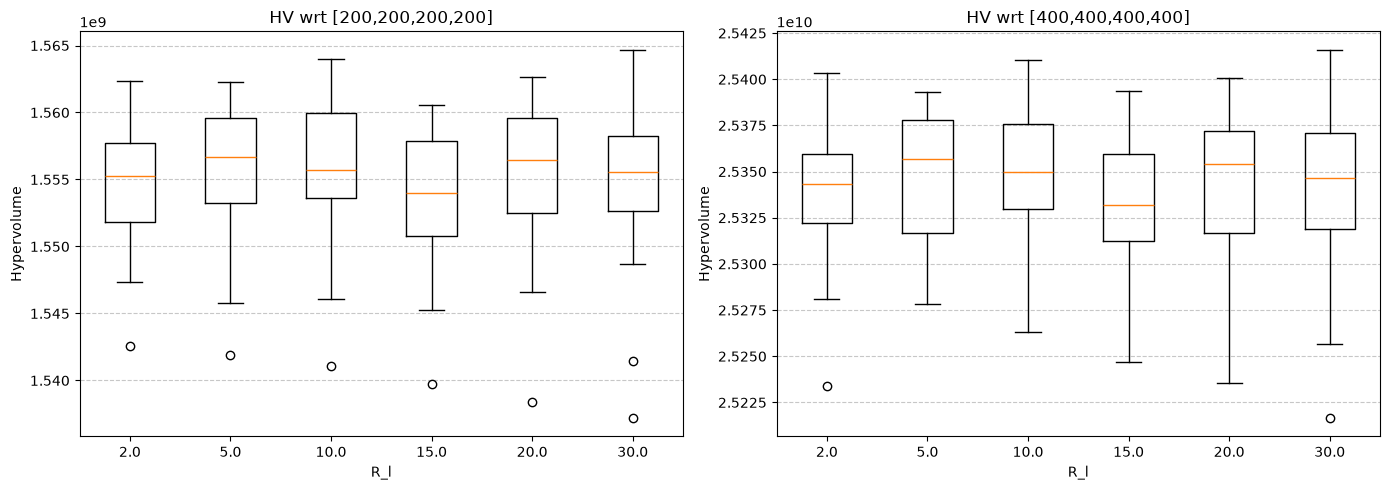

In [4]:
# ==========================================
# Tuning Summary & Visualization
# ==========================================
print("================ TUNING SUMMARY ================")
print(f"{'R_l':<7} | {'Mean HV200':<14} | {'Std HV200':<11} | {'Mean HV400':<15} | {'Std HV400':<11} | {'Avg Sols':<10}")
print("-" * 80)

best_mean_hv = -np.inf
best_rl = R_L_CANDIDATES[0]
for rl in R_L_CANDIDATES:
    m200 = np.mean(tuning_results_200[rl])
    s200 = np.std(tuning_results_200[rl])
    m400 = np.mean(tuning_results_400[rl])
    s400 = np.std(tuning_results_400[rl])
    avg_sols = np.mean([len(F) for F in tuning_solutions_F[rl]])
    print(f"{rl:<7} | {m200:<14.4f} | {s200:<11.4f} | {m400:<15.4f} | {s400:<11.4f} | {avg_sols:<10.1f}")
    if m200 > best_mean_hv:
        best_mean_hv = m200
        best_rl = rl

print(f"\nBest R_l by mean HV200: {best_rl}")
BEST_R_L = best_rl

# Boxplot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.boxplot([tuning_results_200[rl] for rl in R_L_CANDIDATES], tick_labels=R_L_CANDIDATES)
ax1.set_title("HV wrt [200,200,200,200]")
ax1.set_xlabel("R_l")
ax1.set_ylabel("Hypervolume")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2.boxplot([tuning_results_400[rl] for rl in R_L_CANDIDATES], tick_labels=R_L_CANDIDATES)
ax2.set_title("HV wrt [400,400,400,400]")
ax2.set_xlabel("R_l")
ax2.set_ylabel("Hypervolume")
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

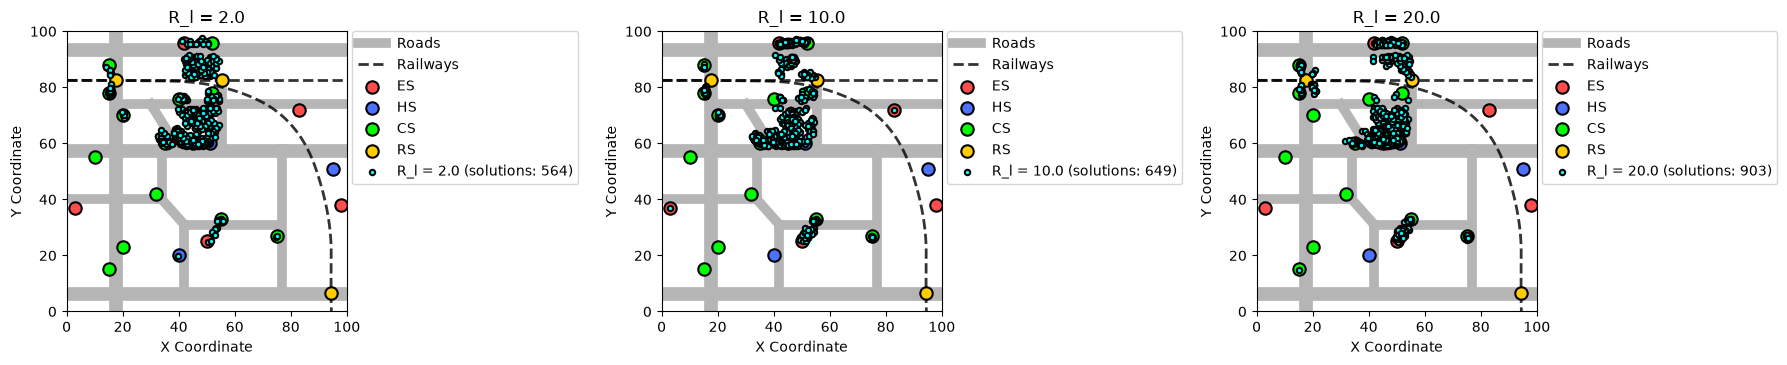

Using BEST_R_L = 10.0 for subsequent comparisons.


In [5]:
# Map visualization for selected R_l values
rl_sample = [2.0, 10.0, 20.0]  # low, medium, high

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, rl in zip(axes, rl_sample):
    last_run_X = tuning_solutions_X[rl][-1] if len(tuning_solutions_X[rl][-1]) > 0 else None
    label = f"R_l = {rl} (solutions: {len(tuning_solutions_F[rl][-1])})" if last_run_X is not None else f"R_l = {rl} (no solutions)"
    plot_city_map_with_solutions(
        facilities, infrastructure, map_styles,
        last_run_X,
        label=label,
        color="#00ffff", marker="o", size=15, ax=ax
    )
    ax.set_title(f"R_l = {rl}")
plt.tight_layout()
plt.show()

print(f"Using BEST_R_L = {BEST_R_L} for subsequent comparisons.")

---
## 2. Fair Comparison Methodology

A key challenge in comparing PSO-based algorithms (PSO-DN, MOPSO-CD) with genetic algorithms (NSGA-II/III)
is that the PSO variants maintain a **global archive** (GBA) that accumulates non-dominated solutions across
all iterations, while NSGA-II/III only return the non-dominated front from the **final population**.

To ensure a fair comparison, we attach a pymoo `Callback` to the NSGA algorithms that extracts the
population at each generation and feeds it into the same `Archive.update_with_dominance()` method
used by the custom PSO algorithms. This gives NSGA-II/III the same archival capability.

In [6]:
class ArchiveCallback(Callback):
    """
    Pymoo callback that collects non-dominated solutions from each generation
    into an Archive, simulating the same archival behavior as the custom PSO optimizers.
    """
    def __init__(self, global_archive):
        super().__init__()
        self.global_archive = global_archive

    def notify(self, algorithm):
        pop_X = algorithm.pop.get("X")
        pop_F = algorithm.pop.get("F")
        self.global_archive.update_with_dominance(pop_X, pop_F)

---
## 3. Algorithm Comparison on the Original Map

We compare the four algorithms over 30 independent runs with shared random seeds.
Three Hypervolume reference points are used:
- **HV200**: fixed reference at [200, 200, 200, 200]
- **HV400**: fixed reference at [400, 400, 400, 400]
- **HV_dyn**: reference computed globally as $1.1 \times \max(F)$ over all algorithms and all 30 runs combined, then applied uniformly to every run.

Unlike a per-run reference (which would make HV values incomparable across runs), this single global reference ensures
all metric values are on the same scale and can be meaningfully averaged.

In [7]:
# Parameters for the comparison

algorithms_dict = {
    "PSO-DN": lambda: PSODN(pop_size=POP_SIZE, n_iter=N_ITER_COMPARISON, R_l=BEST_R_L,
                             w=W, c1=C1, c2=C2, v_bounds=v_bounds),
    "MOPSO-CD": lambda: MOPSO_CD(pop_size=POP_SIZE, n_iter=N_ITER_COMPARISON, Q=10000,
                                  tourn_size=2, w=W, c1=C1, c2=C2, v_bounds=v_bounds),
    "NSGA-II": lambda: NSGA2(pop_size=POP_SIZE),
    "NSGA-III": lambda: NSGA3(pop_size=POP_SIZE, ref_dirs=get_reference_directions("das-dennis", M, n_partitions=9))
}
algo_names = list(algorithms_dict.keys())
n_algo = len(algo_names)

In [14]:
# ==========================================
# Main Comparison Loop (Original Map)
# ==========================================
MAIN_CACHE = os.path.join(CACHE_DIR, 'comparison_main.json')

if FORCE_RECOMPUTE or not os.path.exists(MAIN_CACHE):
    algo_hv200 = {a: [] for a in algo_names}
    algo_hv400 = {a: [] for a in algo_names}
    algo_hvdyn = {a: [] for a in algo_names}
    algo_nsols = {a: [] for a in algo_names}
    algo_X = {a: [] for a in algo_names}
    algo_F = {a: [] for a in algo_names}

    print("Starting Algorithm Comparison on Original Map...\n")
    for run_idx, seed in enumerate(tqdm(MASTER_SEEDS[:N_RUNS_MAIN], desc="Comparison (orig map)")):

        for algo_name in algo_names:
            np.random.seed(seed)

            if algo_name in ["PSO-DN", "MOPSO-CD"]:
                optimizer = algorithms_dict[algo_name]()
                archive, _ = optimizer.optimize(problem, verbose=False)
                X, F = archive.extract_arrays()
            else:
                optimizer = algorithms_dict[algo_name]()
                gba = Archive()
                callback = ArchiveCallback(gba)
                res = minimize(pymoo_problem, optimizer, ('n_gen', N_ITER_COMPARISON),
                               seed=seed, callback=callback, verbose=False)
                gba.remove_similar_solutions(decimals=4)
                X, F = gba.extract_arrays()

            X_clean, F_clean = problem.impose_infrastructure_constraints(X, F)
            algo_X[algo_name].append(X_clean)
            algo_F[algo_name].append(F_clean)
            algo_nsols[algo_name].append(len(F_clean))

            h200 = hv_200(F_clean) if len(F_clean) > 0 else 0.0
            h400 = hv_400(F_clean) if len(F_clean) > 0 else 0.0
            algo_hv200[algo_name].append(h200)
            algo_hv400[algo_name].append(h400)

    # Single global dynamic HV reference point (over all runs x all algorithms)
    all_F_global = np.vstack([F_arr for a in algo_names for F_arr in algo_F[a] if len(F_arr) > 0])
    if len(all_F_global) > 0:
        global_dyn_ref = np.max(all_F_global, axis=0) * 1.1
        hv_global_dyn = HV(ref_point=global_dyn_ref)
        for a in algo_names:
            algo_hvdyn[a] = [float(hv_global_dyn(F_arr)) if len(F_arr) > 0 else 0.0 for F_arr in algo_F[a]]
    else:
        for a in algo_names:
            algo_hvdyn[a] = [0.0] * len(algo_F[a])

    # Save cache
    cache = {
        '_meta': {'global_dyn_ref': global_dyn_ref.tolist() if len(all_F_global) > 0 else None},
        'hv200': {a: algo_hv200[a] for a in algo_names},
        'hv400': {a: algo_hv400[a] for a in algo_names},
        'hvdyn': {a: algo_hvdyn[a] for a in algo_names},
        'nsols': {a: algo_nsols[a] for a in algo_names},
        'X_all': {a: [arr.tolist() for arr in algo_X[a]] for a in algo_names},
        'F_all': {a: [arr.tolist() for arr in algo_F[a]] for a in algo_names},
    }
    with open(MAIN_CACHE, 'w') as f:
        json.dump(cache, f, indent=2)
    print(f"Results cached to {MAIN_CACHE}")
else:
    with open(MAIN_CACHE, 'r') as f:
        cache = json.load(f)
    algo_hv200 = cache['hv200']
    algo_hv400 = cache['hv400']
    algo_hvdyn = cache['hvdyn']
    algo_nsols = cache['nsols']
    algo_X = {a: [np.array(arr) for arr in cache['X_all'][a]] for a in algo_names}
    algo_F = {a: [np.array(arr) for arr in cache['F_all'][a]] for a in algo_names}
    print(f"Loaded tuning results from cache ({MAIN_CACHE})")


Loaded tuning results from cache (c:\Users\silvi\Desktop\UNI\GlobalOpt\pso-dn-mmop\results\comparison_main.json)


Algorithm  | Mean HV200    | Std HV200   | Mean HV400      | Std HV400   | Mean HVdyn    | Std HVdyn   | Mean Sols  | Std Sols  
--------------------------------------------------------------------------------------------------------------
PSO-DN     | 1557028944.4427 | 5250900.8753 | 25357117303.0814 | 40716017.2566 | 3769096.1190  | 90203.5735  | 724.3      | 213.44    
MOPSO-CD   | 1556563809.0974 | 3957817.3616 | 25345786159.4738 | 33953556.3848 | 3831074.7472  | 25565.3759  | 2710.5     | 400.03    
NSGA-II    | 1564141428.8920 | 1076921.1971 | 25405850881.5699 | 9672954.8354 | 3898621.4499  | 4716.9462   | 1525.2     | 64.23     
NSGA-III   | 1563462534.0329 | 1394677.9026 | 25399268888.2315 | 12917739.9390 | 3897791.9838  | 6247.0826   | 2178.4     | 91.30     


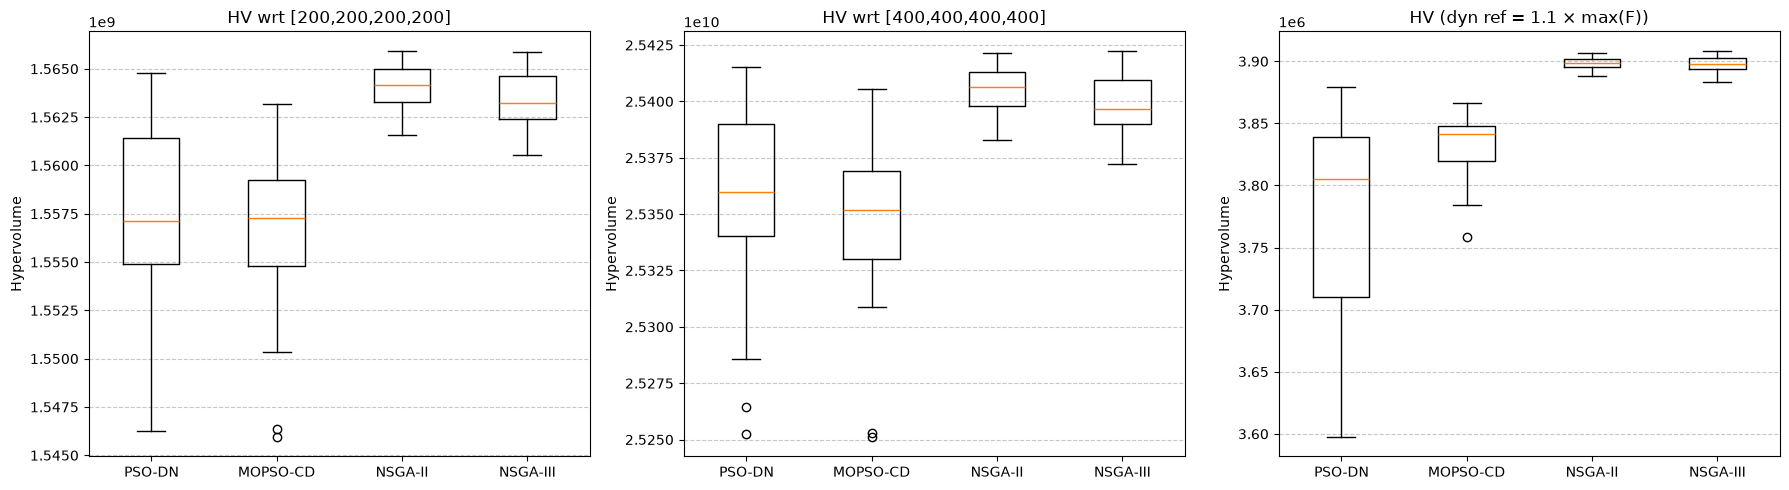

In [15]:
# ==========================================
# Comparison Results: Summary Table
# ==========================================
print("=" * 110)
print(f"{'Algorithm':<10} | {'Mean HV200':<13} | {'Std HV200':<11} | {'Mean HV400':<15} | {'Std HV400':<11} | {'Mean HVdyn':<13} | {'Std HVdyn':<11} | {'Mean Sols':<10} | {'Std Sols':<10}")
print("-" * 110)

for algo_name in algo_names:
    m200 = np.mean(algo_hv200[algo_name])
    s200 = np.std(algo_hv200[algo_name])
    m400 = np.mean(algo_hv400[algo_name])
    s400 = np.std(algo_hv400[algo_name])
    mdyn = np.mean(algo_hvdyn[algo_name])
    sdyn = np.std(algo_hvdyn[algo_name])
    msol = np.mean(algo_nsols[algo_name])
    ssol = np.std(algo_nsols[algo_name])
    print(f"{algo_name:<10} | {m200:<13.4f} | {s200:<11.4f} | {m400:<15.4f} | {s400:<11.4f} | {mdyn:<13.4f} | {sdyn:<11.4f} | {msol:<10.1f} | {ssol:<10.2f}")

# Boxplot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    [algo_hv200, algo_hv400, algo_hvdyn],
    ["HV wrt [200,200,200,200]", "HV wrt [400,400,400,400]", "HV (dyn ref = 1.1 × max(F))"]
):
    ax.boxplot([metric[a] for a in algo_names], tick_labels=algo_names)
    ax.set_title(title)
    ax.set_ylabel("Hypervolume")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

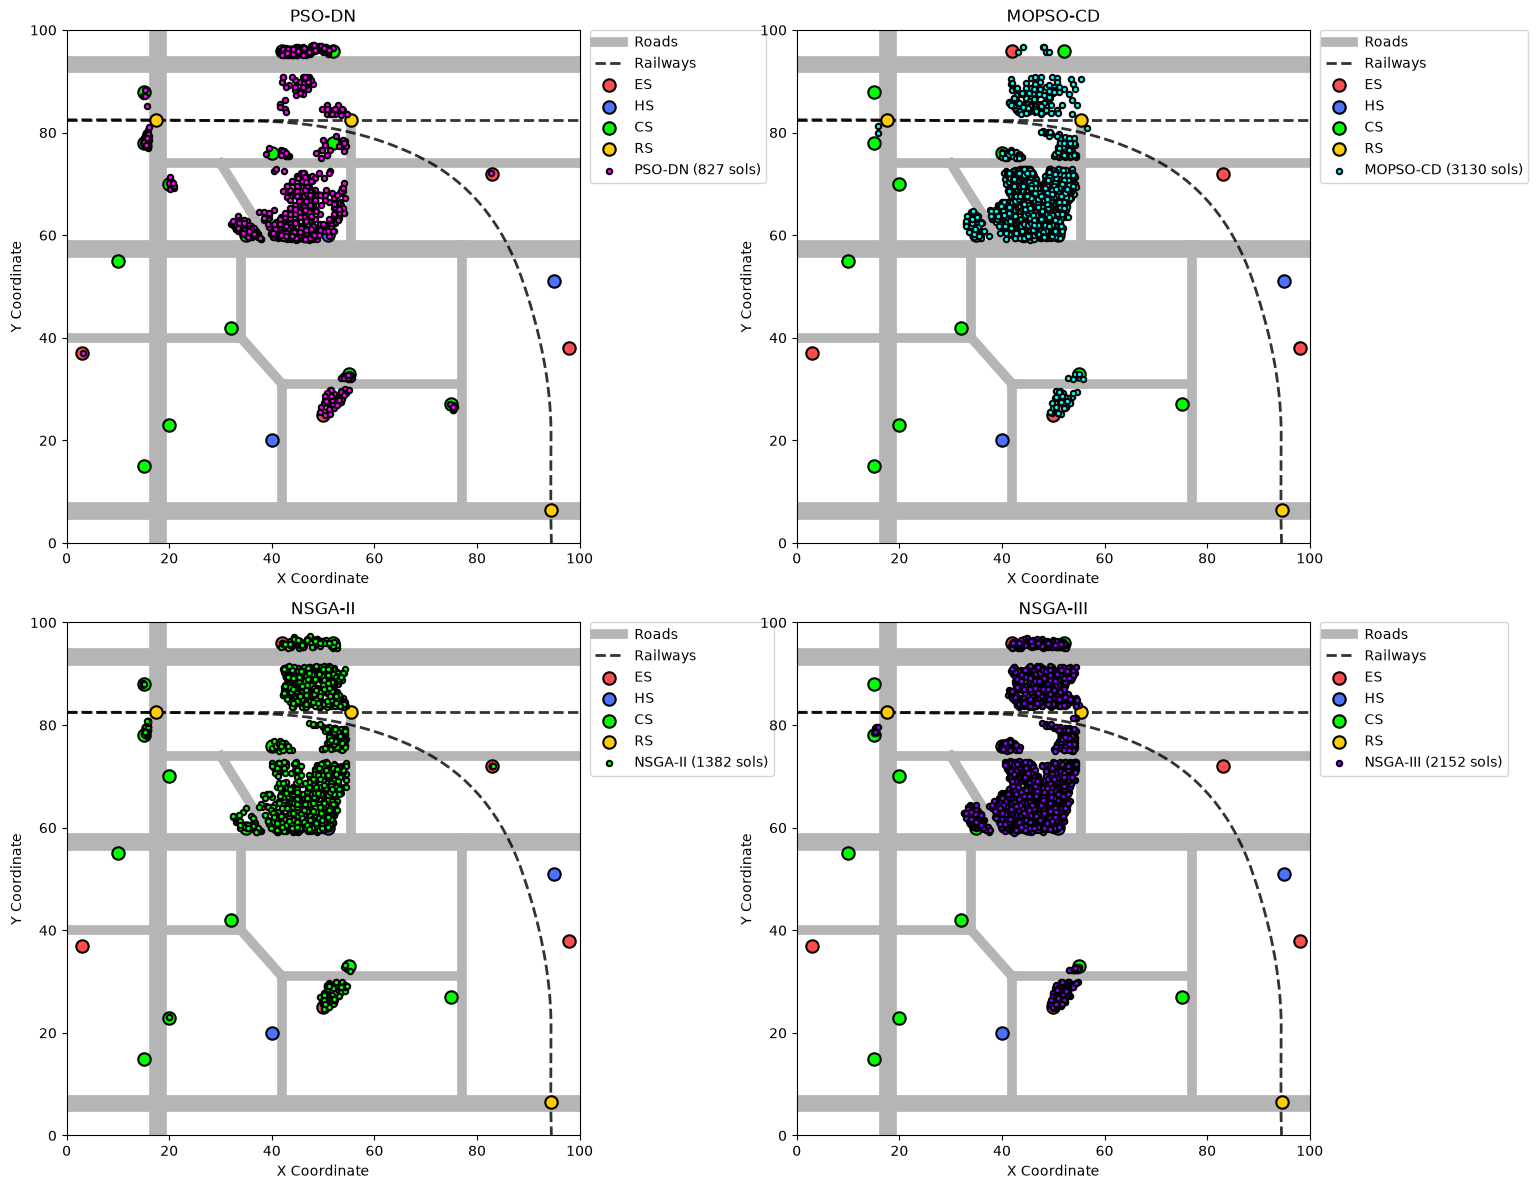

In [16]:
# 4-panel map visualization (last run of each algorithm)
# Solutions are only available if FORCE_RECOMPUTE was True
if any(len(v) > 0 for v in algo_X.values()):
    last_run_X = [algo_X[a][-1] for a in algo_names]
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    colors = ["#ff00ff", "#00ffff", "#00ff00", "#8400ff"]
    for ax, X, name, color in zip(axes.flatten(), last_run_X, algo_names, colors):
        if len(X) > 0:
            plot_city_map_with_solutions(
                facilities, infrastructure, map_styles,
                X, label=f"{name} ({len(X)} sols)",
                color=color, marker="o", size=15, ax=ax
            )
        ax.set_title(name)
    plt.tight_layout()
    plt.show()
else:
    print("Solution arrays not available.")

---
## 4. Benchmark on DTLZ3

We validate the optimizers on the **DTLZ3** benchmark (13 variables, 4 objectives, many local Pareto fronts)
to test each algorithm's ability to preserve diversity and escape local optima.

**Why DTLZ3 with M=4:**
- DTLZ3 has $3^K = 3^{10} = 59049$ **local Pareto fronts** (where $K = n_{var} - M + 1 = 10$) that can trap classical optimizers
- The **#Fronts** metric counts how many distinct local fronts each algorithm discovers, directly measuring diversity preservation
- 4 objectives allows all four algorithms (including NSGA-III) to participate
- The true Pareto front is known (same as DTLZ2: $\sum f_i^2 = 1$), enabling IGD computation

**DTLZ3 Reference**: Deb, Thiele, Laumanns, Zitzler. "Scalable Test Problems for Evolutionary Multi-Objective Optimization."

**Metrics:**
- **HV**: Hypervolume with fixed ref point $[5,5,5,5]$
- **HV_dyn**: Dynamic HV with global ref point $1.1 \times \max(F)$ (computed post-hoc over all runs)
- **IGD**: Inverted Generational Distance to the true Pareto front
- **#Fronts**: number of distinct $g$ values among non-dominated solutions, where $g = \sqrt{\sum f_i^2} - 1$. Each distinct $g$ corresponds to a different local Pareto front.
- **#Sols**: number of non-dominated solutions found

In [17]:
# ==========================================
# DTLZ3 Wrapper
# ==========================================
class DTLZ3Wrapper:
    """Wraps pymoo's DTLZ3 into the interface expected by PSODN and MOPSO_CD."""
    def __init__(self, n_obj=4, n_var=13):
        self.problem = get_problem("dtlz3", n_obj=n_obj, n_var=n_var)
        self.D = n_var
        self.x_bounds = np.column_stack((self.problem.xl, self.problem.xu))
        self.M = n_obj

    def evaluate_population(self, X):
        return self.problem.evaluate(X)

dtlz3 = DTLZ3Wrapper(n_obj=4, n_var=13)
# Compute PF manually: DTLZ3's _calc_pareto_front raises for M > 3
ref_dirs_pf = get_reference_directions("das-dennis", dtlz3.M, n_partitions=12)
pf_true_dtlz3 = ref_dirs_pf / np.sqrt(np.sum(ref_dirs_pf**2, axis=1, keepdims=True))

# Adjust v_bounds for DTLZ3 (variables in [0, 1])
dtlz3_v_bounds = np.array([[0.001, 1.0]] * dtlz3.D)

# Pymoo wrapper for DTLZ3
dtlz3_pymoo = dtlz3.problem

# Reference point & metrics
dtlz3_ref = np.array([1000.0] * dtlz3.M)
hv_dtlz3 = HV(ref_point=dtlz3_ref)
igd_dtlz3 = IGD(pf_true_dtlz3)

In [18]:
# ==========================================
# DTLZ3 Comparison Loop
# ==========================================
DTLZ3_CACHE = os.path.join(CACHE_DIR, 'comparison_dtlz3.json')

dtlz3_algorithms = {
    "PSO-DN": lambda: PSODN(pop_size=220, n_iter=200, R_l=0.1,
                             w=W, c1=C1, c2=C2, v_bounds=dtlz3_v_bounds),
    "MOPSO-CD": lambda: MOPSO_CD(pop_size=220, n_iter=200, Q=10000, tourn_size=2,
                                  w=W, c1=C1, c2=C2, v_bounds=dtlz3_v_bounds),
    "NSGA-II": lambda: NSGA2(pop_size=220),
    "NSGA-III": lambda: NSGA3(pop_size=220,
                                ref_dirs=get_reference_directions("das-dennis", dtlz3.M, n_partitions=9)),
}
dtlz3_names = list(dtlz3_algorithms.keys())

if FORCE_RECOMPUTE or not os.path.exists(DTLZ3_CACHE):
    d_hv = {a: [] for a in dtlz3_names}
    d_hvdyn = {a: [] for a in dtlz3_names}
    d_igd = {a: [] for a in dtlz3_names}
    d_nfronts = {a: [] for a in dtlz3_names}
    d_nsols = {a: [] for a in dtlz3_names}
    d_F = {a: [] for a in dtlz3_names}

    print("Starting DTLZ3 Benchmark...\n")
    for run_idx, seed in enumerate(tqdm(MASTER_SEEDS[:N_RUNS_QUICK], desc="DTLZ3 runs")):
        for algo_name in dtlz3_names:
            np.random.seed(seed)

            if algo_name in ["PSO-DN", "MOPSO-CD"]:
                optimizer = dtlz3_algorithms[algo_name]()
                archive, _ = optimizer.optimize(dtlz3, verbose=False)
                X, F = archive.extract_arrays()
            else:
                optimizer = dtlz3_algorithms[algo_name]()
                gba = Archive()
                callback = ArchiveCallback(gba)
                res = minimize(dtlz3_pymoo, optimizer, ('n_gen', 200),
                               seed=seed, callback=callback, verbose=False)
                gba.remove_similar_solutions(decimals=4)
                X, F = gba.extract_arrays()

            d_F[algo_name].append(F)
            d_nsols[algo_name].append(len(F))

            if len(F) > 0:
                d_hv[algo_name].append(hv_dtlz3(F))
                d_igd[algo_name].append(igd_dtlz3(F))
                # #Fronts: count distinct g values (g = sqrt(sum(f_i^2)) - 1)
                g_vals = np.sqrt(np.sum(F**2, axis=1)) - 1.0
                unique_gs = np.unique(np.round(g_vals, decimals=3))
                d_nfronts[algo_name].append(len(unique_gs))
            else:
                d_hv[algo_name].append(0.0)
                d_igd[algo_name].append(999.0)
                d_nfronts[algo_name].append(0)

    # Single global dynamic HV reference point (over all runs x all algorithms)
    all_F_list = [F_arr for a in dtlz3_names for F_arr in d_F[a] if len(F_arr) > 0]
    if all_F_list:
        all_F_global = np.vstack(all_F_list)
        global_dyn_ref = np.max(all_F_global, axis=0) * 1.1
        hv_global_dyn = HV(ref_point=global_dyn_ref)
        for a in dtlz3_names:
            d_hvdyn[a] = [float(hv_global_dyn(F_arr)) if len(F_arr) > 0 else 0.0 for F_arr in d_F[a]]
    else:
        for a in dtlz3_names:
            d_hvdyn[a] = [0.0] * len(d_F[a])
        global_dyn_ref = None

    cache = {
        '_meta': {'global_dyn_ref': global_dyn_ref.tolist() if all_F_list else None, 'n_obj': dtlz3.M, 'n_var': dtlz3.D},
        'hv': {a: d_hv[a] for a in dtlz3_names},
        'hvdyn': {a: d_hvdyn[a] for a in dtlz3_names},
        'igd': {a: d_igd[a] for a in dtlz3_names},
        'nfronts': {a: d_nfronts[a] for a in dtlz3_names},
        'nsols': {a: d_nsols[a] for a in dtlz3_names},
    }
    with open(DTLZ3_CACHE, 'w') as f:
        json.dump(cache, f, indent=2)
    print(f"Results cached to {DTLZ3_CACHE}")
else:
    with open(DTLZ3_CACHE, 'r') as f:
        cache = json.load(f)
    d_hv = cache['hv']
    d_hvdyn = cache['hvdyn']
    d_igd = cache['igd']
    d_nfronts = cache['nfronts']
    d_nsols = cache['nsols']
    print(f"Loaded DTLZ3 results from cache ({DTLZ3_CACHE})")

Loaded DTLZ3 results from cache (c:\Users\silvi\Desktop\UNI\GlobalOpt\pso-dn-mmop\results\comparison_dtlz3.json)


Algorithm  | Mean HV    | Std HV     | Mean HVdyn   | Std HVdyn    | Mean IGD   | Std IGD    | #Fronts   | #Sols  
--------------------------------------------------------------------------------------------------------------
PSO-DN     | 911766619120.2456 | 124510539445.5977 | 4738510952116.1201 | 192722429387.2284 | 273.9597   | 162.3983   | 82.5      | 82.5   
MOPSO-CD   | 998886135397.2896 | 149698215.4753 | 4873993076371.3447 | 149698215.4751 | 171.2168   | 11.0824    | 98.8      | 99.1   
NSGA-II    | 999985710184.2361 | 6936586.3839 | 4875092651156.3027 | 6936585.4432 | 49.4077    | 8.4986     | 460.3     | 468.3  
NSGA-III   | 999999998555.6096 | 1911.0111  | 4875106939529.6572 | 1911.0117    | 4.0593     | 1.9670     | 404.0     | 411.1  


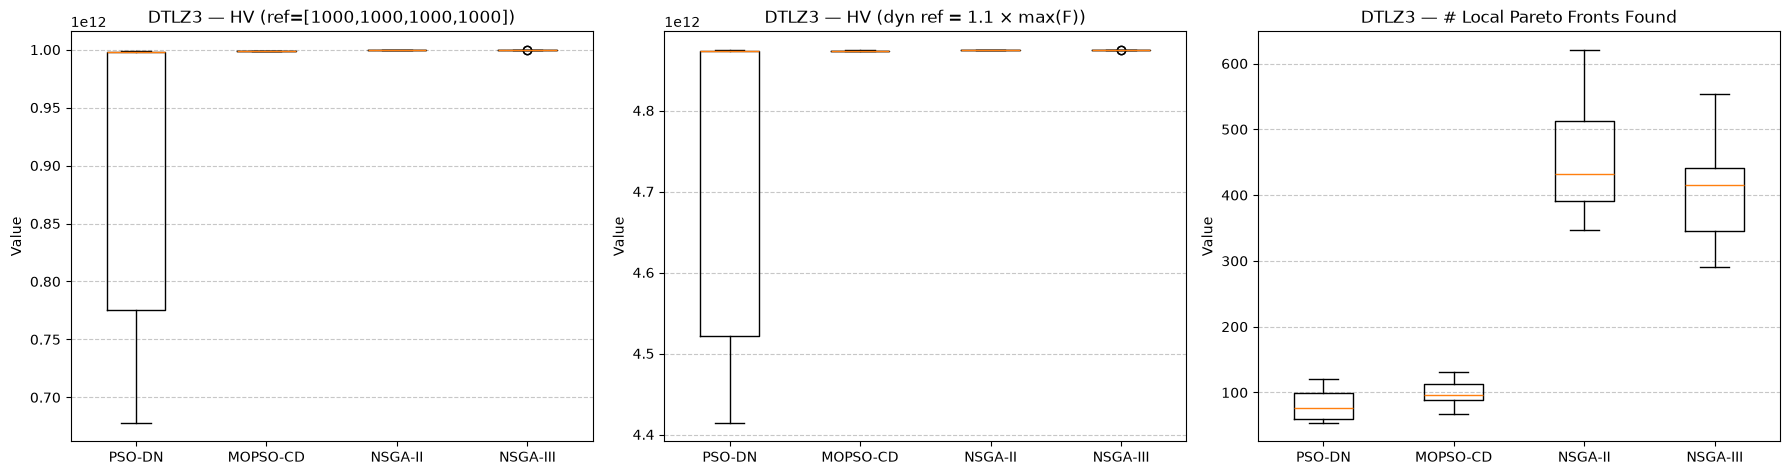

In [19]:
# DTLZ3 results
print("=" * 110)
print(f"{'Algorithm':<10} | {'Mean HV':<10} | {'Std HV':<10} | {'Mean HVdyn':<12} | {'Std HVdyn':<12} | {'Mean IGD':<10} | {'Std IGD':<10} | {'#Fronts':<9} | {'#Sols':<7}")
print("-" * 110)
for a in dtlz3_names:
    m_hv = np.mean(d_hv[a])
    s_hv = np.std(d_hv[a])
    m_dyn = np.mean(d_hvdyn[a])
    s_dyn = np.std(d_hvdyn[a])
    m_igd = np.mean(d_igd[a])
    s_igd = np.std(d_igd[a])
    m_nf = np.mean(d_nfronts[a])
    m_ns = np.mean(d_nsols[a])
    print(f"{a:<10} | {m_hv:<10.4f} | {s_hv:<10.4f} | {m_dyn:<12.4f} | {s_dyn:<12.4f} | {m_igd:<10.4f} | {s_igd:<10.4f} | {m_nf:<9.1f} | {m_ns:<7.1f}")

# Boxplot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(
    axes,
    [d_hv, d_hvdyn, d_nfronts],
    ["HV (ref=[1000,1000,1000,1000])", "HV (dyn ref = 1.1 × max(F))", "# Local Pareto Fronts Found"]
):
    ax.boxplot([metric[a] for a in dtlz3_names], tick_labels=dtlz3_names)
    ax.set_title(f"DTLZ3 — {title}")
    ax.set_ylabel("Value")
    ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
## Summary

| Section | Setup | Runs | Algorithms | Metrics |
|---|---|---|---|---|
| Hyperparameter Tuning | Original map (M=4, K=[6,3,13,3]) | 30 | PSO-DN (varied R_l) | HV200, HV400 |
| Comparison (Original Map) | Same | 30 | PSO-DN, MOPSO-CD, NSGA-II, NSGA-III | HV200, HV400, HVdyn, #solutions |
| Benchmark (DTLZ3) | 13 vars, 4 obj., 59049 local fronts | 15 | PSO-DN, MOPSO-CD, NSGA-II, NSGA-III | HV, HVdyn, IGD, #Fronts, #solutions |

All results are cached in `../results/` for reproducibility. Set `FORCE_RECOMPUTE = True` at the top
of the notebook to regenerate results from scratch.